<a href="https://colab.research.google.com/github/sthefany-vg/Decision-Aid/blob/main/DAPPC_LAB4_FuzzyLogic_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DAPPC LAB 4 - Construction of a clinical score to monitor clinical status evolution

This notebook guides you in the implementation of a **fuzzy inference system (FIS)** to construct a clinical score from the subset of features selected during LAB3.

## Recommended workflow
1. Load the dataset and define the outcome classes.
2. Select the subset of features identified in LAB3.
3. Implement the membership functions already defined graphically.
4. Perform hierarchical clustering separately within each outcome class.
5. Cut the dendrograms, identify the clusters, and compute the cluster centroids.
6. Convert each centroid into a fuzzy rule.
7. Build the fuzzy inference system and compute the final clinical risk score.
8. Analyze the score distribution across the three clinical outcomes.


## 0. Setup

You may have to install some dependencies:
1. the scikit-fuzzy package -> pip install -U scikit-fuzzy
2. the networkx package -> pip install networkx


In [2]:
# ============================================================
# 0. Setup - Instalación de Dependencias
# ============================================================

!pip install -U scikit-fuzzy
!pip install networkx

print("\n=============================================================")
print("🚀 ¡Librerías instaladas y listas para el modelado difuso!")
print("=============================================================")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 13.3 MB/s eta 0:00:00

🚀 ¡Librerías instaladas y listas para el modelado difuso!


In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import MinMaxScaler

import skfuzzy as fuzz
from skfuzzy import control as ctrl

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Load data

Load the dataset obtained after LAB3.

The dataset must contain all the subjects but only some columns:
- the identifiers (which must **not** be used in the model),
- the selected input features,
- the outcome column.


In [5]:
# ============================================================
# 1. Load data
# ============================================================

# Definimos el archivo de Excel y la pestaña por separado, tal como dicta la plantilla
file_path = 'Dataset_DAPPC_2026_Cleaned_kNN.xlsx'
sheet_name = 'SOM_Assignments'

# Cargamos la hoja específica usando la función original de tu guía
df_complete = pd.read_excel(file_path, sheet_name=sheet_name)

# Filtramos las columnas requeridas por el laboratorio para trabajar ordenados:
# Identificadores, las 4 variables del LAB3, el outcome y el ID del cluster
id_cols = ['subject_id', 'hadm_id', 'stay_id']
selected_features = ['comorb_respiratory_pulmonary', 'opioids', 'comorb_total', 'neuromuscular_blockers']
outcome_col = ['outcome']
cluster_col = ['som_cluster_id']

df = df_complete[id_cols + selected_features + outcome_col + cluster_col].copy()

# Impresión oficial de la guía
print('Dataset shape:', df.shape)
display(df.head())


Dataset shape: (3893, 9)


,subject_id,hadm_id,stay_id,comorb_respiratory_pulmonary,opioids,comorb_total,neuromuscular_blockers,outcome,som_cluster_id
0,13710366,26676995,36043579,0,1,1,1,1,2
1,12970079,23949170,36004625,1,1,2,1,2,2
2,17682100,22097504,34901461,0,1,1,0,1,2
3,15545849,24922530,39025631,0,1,3,0,3,2
4,10288279,21750307,34078845,0,1,3,0,3,2


## 2. Define the outcome column and the selected feature subset

Use the subset of predictors identified in LAB3.

Do **not** include IDs or other non-informative columns.


In [7]:
# ============================================================
# 2. Define the outcome column and the selected feature subset
# ============================================================

outcome_col = 'outcome'
selected_features = [
    'comorb_respiratory_pulmonary',
    'opioids',
    'comorb_total',
    'neuromuscular_blockers'
]

print('Selected features:', selected_features)
print('Number of selected features:', len(selected_features))
print('Class distribution:')
display(df[outcome_col].value_counts(dropna=False))


Selected features: ['comorb_respiratory_pulmonary', 'opioids', 'comorb_total', 'neuromuscular_blockers']
Number of selected features: 4
Class distribution:


,count
outcome,
2,1264
3,1099
1,844
4,362
0,283
5,41


___
# PART 1: MFs DEFINITION

## 3. Define the fuzzy variables and the membership functions

The membership functions were already identified graphically.
In this step, simply translate them into Python.

For each input feature (`Antecedent`):
1. define the range (i.e., the `universe`),
2. create the fuzzy variable,
3. assign the MFs using `trimf` (triangular MF) and/or `trapmf` (trapezoidal MF).

The final output (`Consequent`) is a continuous variable called `clinical_risk`.


In [12]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# ============================================================
# 3. Define the fuzzy variables and the membership functions
# ============================================================

# Diccionario para almacenar las variables de entrada (Antecedents)
fuzzy_inputs = {}

# ------------------------------------------------------------
# A. Configuración para Variables Binarias (0 o 1)
# ------------------------------------------------------------
# Universo continuo de 0 a 1 con pasos de 0.01 para suavidad matemática
binary_universe = np.arange(0, 1.01, 0.01)
binary_features = ['comorb_respiratory_pulmonary', 'opioids', 'neuromuscular_blockers']

for feat in binary_features:
    # Creamos el Antecedente
    fuzzy_inputs[feat] = ctrl.Antecedent(binary_universe, feat)

    # Definimos las MFs triangulares:
    # 'absent' es 1 en el valor 0 y decae hacia 1. 'present' empieza en 0 y es 1 en el valor 1.
    fuzzy_inputs[feat]['absent'] = fuzz.trimf(fuzzy_inputs[feat].universe, [0, 0, 1])
    fuzzy_inputs[feat]['present'] = fuzz.trimf(fuzzy_inputs[feat].universe, [0, 1, 1])

# ------------------------------------------------------------
# B. Configuración para 'comorb_total' (Rango real: 0 a 5)
# ------------------------------------------------------------
# Universo de 0 a 5 con pasos de 0.01
comorb_universe = np.arange(0, 5.01, 0.01)
fuzzy_inputs['comorb_total'] = ctrl.Antecedent(comorb_universe, 'comorb_total')

# Asignamos funciones de pertenencia según lógica clínica (ajusta los puntos si tu PDF varía)
# 'low': Trapezoidal, máxima pertenencia para 0 y 1 comorbilidades.
fuzzy_inputs['comorb_total']['low'] = fuzz.trapmf(fuzzy_inputs['comorb_total'].universe, [0, 0, 1.0, 2.5])
# 'medium': Triangular, centrado en pacientes con un nivel intermedio de patologías.
fuzzy_inputs['comorb_total']['medium'] = fuzz.trimf(fuzzy_inputs['comorb_total'].universe, [1.0, 2.5, 4.0])
# 'high': Trapezoidal, máxima pertenencia para pacientes críticos con 4 o 5 comorbilidades.
fuzzy_inputs['comorb_total']['high'] = fuzz.trapmf(fuzzy_inputs['comorb_total'].universe, [2.5, 4.0, 5.0, 5.0])

# ------------------------------------------------------------
# C. Configuración del Consecuente: clinical_risk (0 a 100)
# ------------------------------------------------------------
risk_universe = np.arange(0, 101, 1)
clinical_risk = ctrl.Consequent(risk_universe, 'clinical_risk')

# Definimos los tres niveles de riesgo para el monitoreo en la UCI
clinical_risk['low'] = fuzz.trapmf(clinical_risk.universe, [0, 0, 20, 45])
clinical_risk['medium'] = fuzz.trimf(clinical_risk.universe, [30, 50, 70])
clinical_risk['high'] = fuzz.trapmf(clinical_risk.universe, [55, 80, 100, 100])

# ============================================================
# Verificación Visual (Opcional - Quita los '#' si quieres ver los gráficos)
# ============================================================
# fuzzy_inputs['comorb_total'].view()
# clinical_risk.view()

print("=============================================================")
print("🚀 Variables difusas (Antecedentes y Consecuente) inicializadas")
print("=============================================================")
print(f"Inputs registrados: {list(fuzzy_inputs.keys())}")
print(f"Output registrado: {clinical_risk.label}")

🚀 Variables difusas (Antecedentes y Consecuente) inicializadas
Inputs registrados: ['comorb_respiratory_pulmonary', 'opioids', 'neuromuscular_blockers', 'comorb_total']
Output registrado: clinical_risk


### 4. Check the membership functions

Visualize all the defined membership functions and compare them with the graphical design developed previously.

This step is important, before moving on, make sure that:
- the numerical ranges are correct,
- the linguistic terms (names of the MFs) are assigned correctly,
- the shapes of the membership functions match the ones defined graphically.

If needed, revise the parameters before proceeding.

Membership functions for: comorb_respiratory_pulmonary


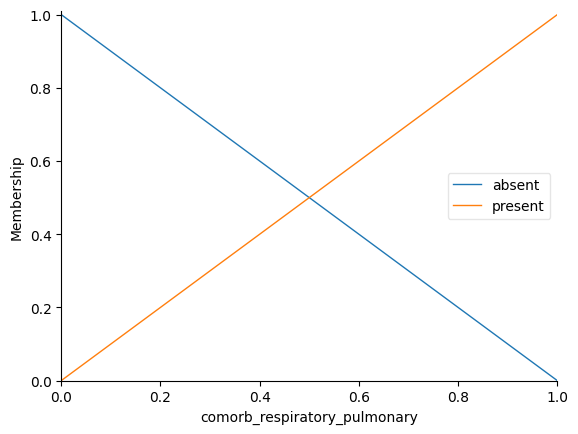

Membership functions for: opioids


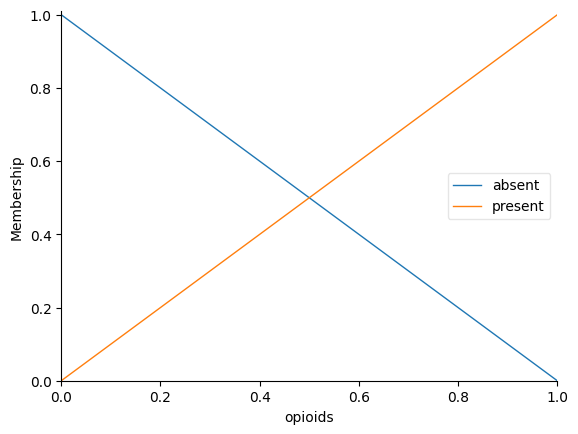

Membership functions for: neuromuscular_blockers


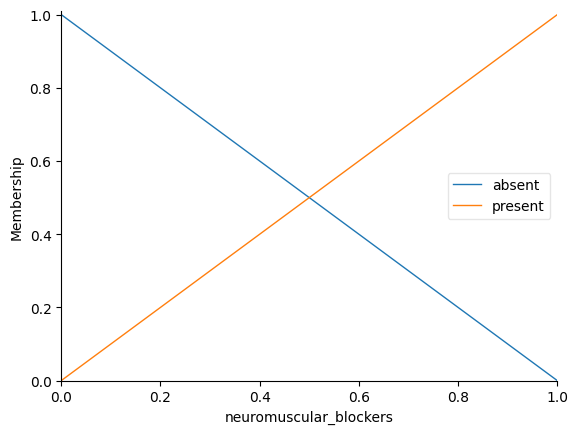

Membership functions for: comorb_total


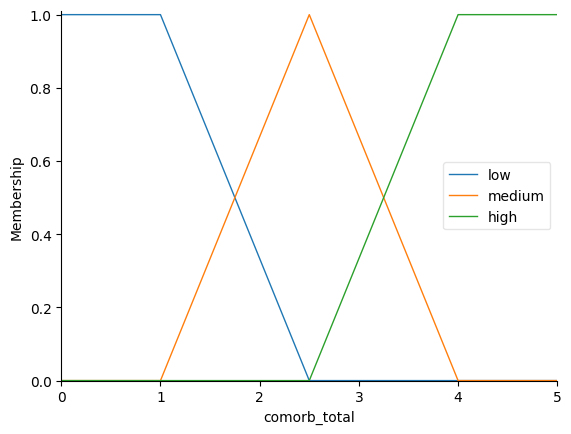

Membership functions for: clinical_risk


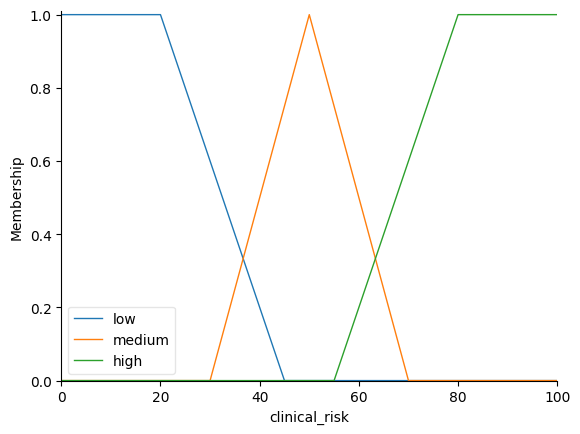

In [13]:
import matplotlib.pyplot as plt

# ============================================================
# 4. Check the membership functions
# ============================================================

# Visualizamos las funciones de pertenencia de cada variable clínica de entrada (Antecedentes)
for feature_name, fuzzy_var in fuzzy_inputs.items():
    print(f"Membership functions for: {feature_name}")
    fuzzy_var.view()
    plt.show() # Forzamos la visualización limpia dentro de la celda de Colab

# Visualizamos la función de pertenencia de la variable de salida (Consecuente)
print("Membership functions for: clinical_risk")
clinical_risk.view()
plt.show()

___
# PART 2: RULES IDENTIFICATION

### 5. Prepare data for clustering
Before splitting the subjects by outcome, apply Min-Max normalization to the selected features.
This step ensures that all variables contribute comparably to the hierarchical clustering procedure.

Note: clustering is performed in the normalized feature space, while the fuzzy membership functions are defined in the original clinical domain. Therefore, cluster centroids must be transformed back to the original scale before generating the fuzzy rules.

In [14]:
from sklearn.preprocessing import MinMaxScaler

# ============================================================
# 5. Prepare data for clustering
# ============================================================

# Select the features identified in LAB3
X = df[selected_features].copy()

# Apply Min-Max normalization before splitting by outcome
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=selected_features,
    index=df.index
)

# Add the outcome column for the next steps (Corregido para usar outcome_col)
df_scaled = X_scaled.copy()
df_scaled[outcome_col] = df[outcome_col]

print("=============================================================")
print("🚀 Datos normalizados con Min-Max y preparados para clustering")
print("=============================================================")
print('df_scaled shape:', df_scaled.shape)
display(df_scaled.head())

🚀 Datos normalizados con Min-Max y preparados para clustering
df_scaled shape: (3893, 5)


,comorb_respiratory_pulmonary,opioids,comorb_total,neuromuscular_blockers,outcome
0,0.0,1.0,0.2,1.0,1
1,1.0,1.0,0.4,1.0,2
2,0.0,1.0,0.2,0.0,1
3,0.0,1.0,0.6,0.0,3
4,0.0,1.0,0.6,0.0,3


## 5. Split the subjects according to the outcome

We want to identify the rules using hierarchical clustering, performed **separately** for each outcome class.
This allows us to identify the main patterns within each clinical condition.


In [15]:
# ============================================================
# 5. Split the subjects according to the outcome
# ============================================================

# Creamos un diccionario para almacenar los subconjuntos de datos normalizados por clase
outcome_subsets = {}

# Obtenemos las clases únicas presentes en la columna de desenlace (usualmente 0, 1, 2)
unique_outcomes = sorted(df_scaled[outcome_col].unique())

print("=============================================================")
print("🚀 División de Pacientes por Clase de Desenlace Clínico")
print("=============================================================")

for outcome_val in unique_outcomes:
    # Filtramos las filas correspondientes a la clase actual y nos quedamos solo con las variables predictoras
    subset = df_scaled[df_scaled[outcome_col] == outcome_val][selected_features].copy()

    # Guardamos en el diccionario
    outcome_subsets[outcome_val] = subset

    print(f"🔹 Clase [Outcome = {outcome_val}]: {subset.shape[0]} pacientes registrados.")
    print(f"   Primeras filas del subgrupo:")
    display(subset.head(2))
    print("-" * 60)

🚀 División de Pacientes por Clase de Desenlace Clínico
🔹 Clase [Outcome = 0]: 283 pacientes registrados.
   Primeras filas del subgrupo:


,comorb_respiratory_pulmonary,opioids,comorb_total,neuromuscular_blockers
10,0.0,1.0,0.0,1.0
21,0.0,1.0,0.0,0.0


------------------------------------------------------------
🔹 Clase [Outcome = 1]: 844 pacientes registrados.
   Primeras filas del subgrupo:


,comorb_respiratory_pulmonary,opioids,comorb_total,neuromuscular_blockers
0,0.0,1.0,0.2,1.0
2,0.0,1.0,0.2,0.0


------------------------------------------------------------
🔹 Clase [Outcome = 2]: 1264 pacientes registrados.
   Primeras filas del subgrupo:


...

------------------------------------------------------------
🔹 Clase [Outcome = 4]: 362 pacientes registrados.
   Primeras filas del subgrupo:


,comorb_respiratory_pulmonary,opioids,comorb_total,neuromuscular_blockers
11,0.0,1.0,0.8,0.0
15,1.0,1.0,0.8,1.0


------------------------------------------------------------
🔹 Clase [Outcome = 5]: 41 pacientes registrados.
   Primeras filas del subgrupo:


,comorb_respiratory_pulmonary,opioids,comorb_total,neuromuscular_blockers
368,1.0,1.0,1.0,0.0
393,1.0,1.0,1.0,0.0


------------------------------------------------------------


## 6. Hierarchical clustering within each outcome class

For each class:
1. use only the selected features,
3. compute the linkage matrix (method complete, metric cityblock),
4. visualize the dendrogram,
5. cut the dendrogram.



 PROCESANDO CLUSTERING JERÁRQUICO PARA OUTCOME: 0


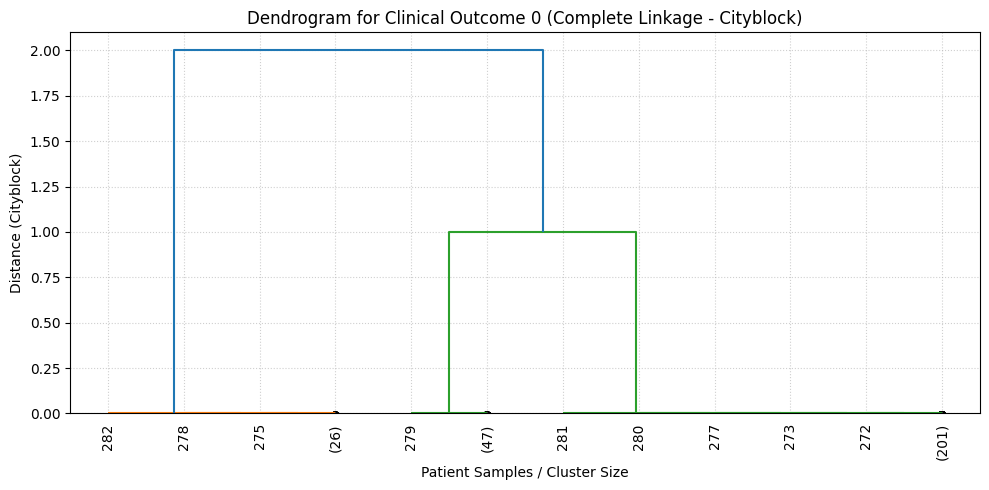

➔ Dendrograma cortado exitosamente en 3 clusters.
   • Sub-Cluster 1: 29 pacientes
   • Sub-Cluster 2: 48 pacientes
   • Sub-Cluster 3: 206 pacientes

 PROCESANDO CLUSTERING JERÁRQUICO PARA OUTCOME: 1


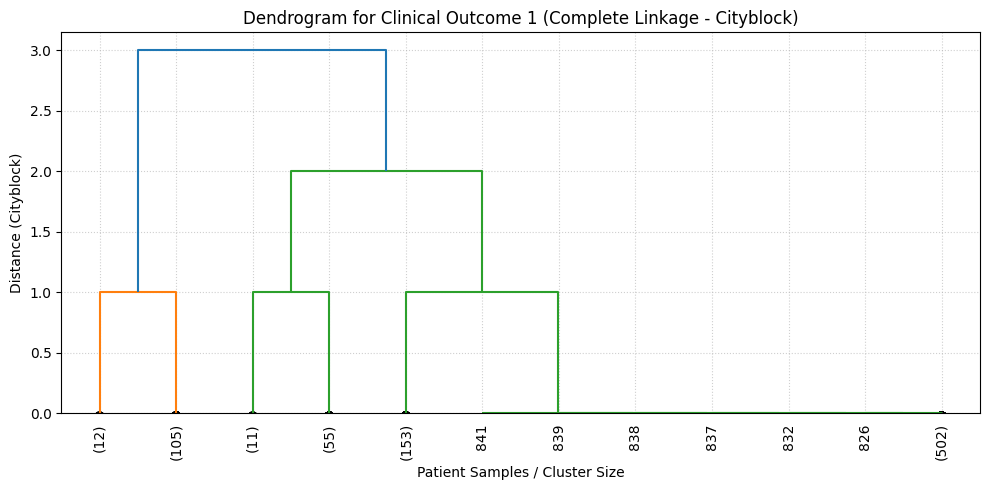

➔ Dendrograma cortado exitosamente en 3 clusters.
   • Sub-Cluster 1: 117 pacientes
   • Sub-Cluster 2: 66 pacientes
   • Sub-Cluster 3: 661 pacientes

 PROCESANDO CLUSTERING JERÁRQUICO PARA OUTCOME: 2


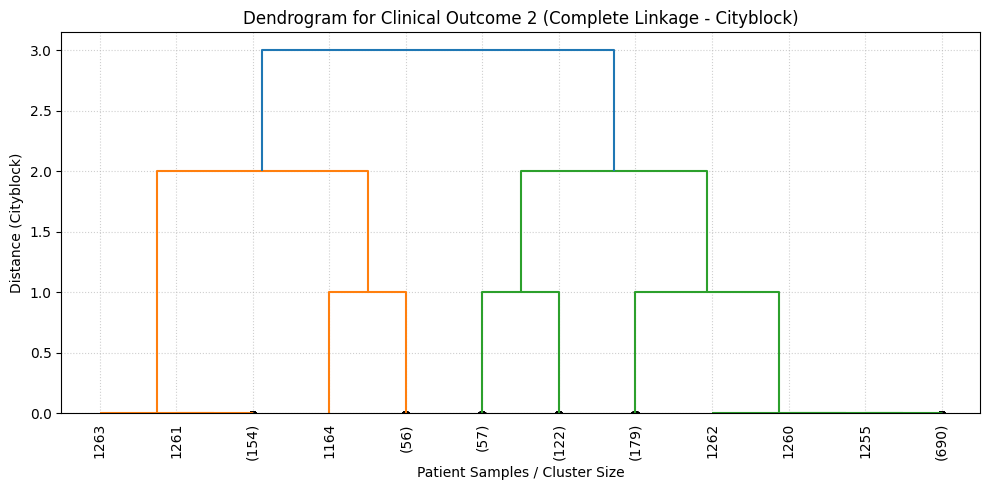

➔ Dendrograma cortado exitosamente en 3 clusters.
   • Sub-Cluster 1: 213 pacientes
   • Sub-Cluster 2: 1051 pacientes

 PROCESANDO CLUSTERING JERÁRQUICO PARA OUTCOME: 3


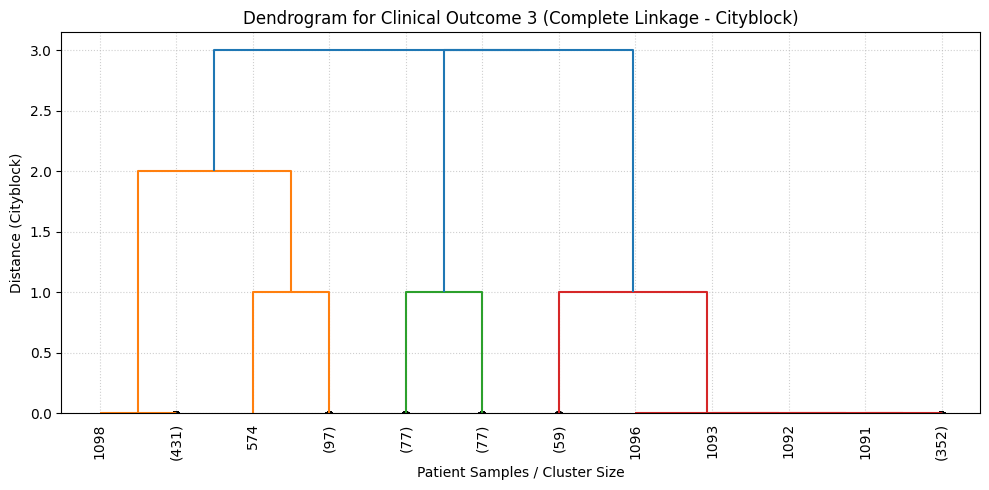

➔ Dendrograma cortado exitosamente en 3 clusters.
   • Sub-Cluster 1: 530 pacientes
   • Sub-Cluster 2: 154 pacientes
   • Sub-Cluster 3: 415 pacientes

 PROCESANDO CLUSTERING JERÁRQUICO PARA OUTCOME: 4


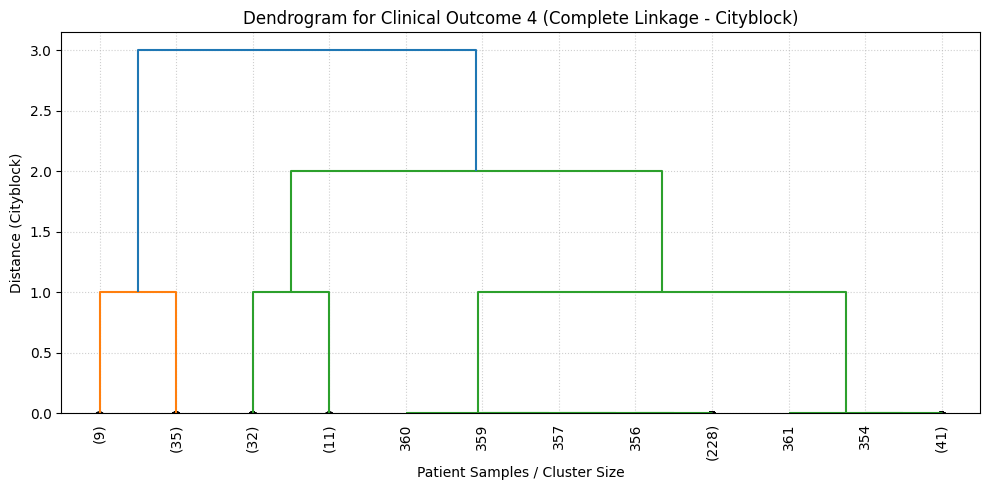

➔ Dendrograma cortado exitosamente en 3 clusters.
   • Sub-Cluster 1: 44 pacientes
   • Sub-Cluster 2: 43 pacientes
   • Sub-Cluster 3: 275 pacientes

 PROCESANDO CLUSTERING JERÁRQUICO PARA OUTCOME: 5


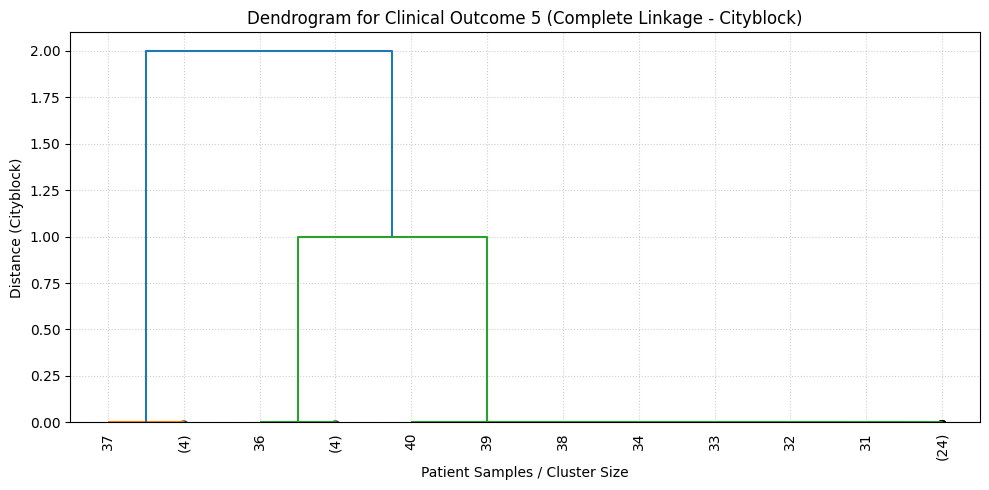

➔ Dendrograma cortado exitosamente en 3 clusters.
   • Sub-Cluster 1: 5 pacientes
   • Sub-Cluster 2: 5 pacientes
   • Sub-Cluster 3: 31 pacientes


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# ============================================================
# 6. Hierarchical clustering within each outcome class
# ============================================================

# Definimos el número de clusters en el que cortaremos cada dendrograma.
# Puedes ajustar este número (por ejemplo, 2, 3 o 4) según lo que observes en las gráficas
# o lo que sugiera la guía de tu cátedra para la cantidad de reglas deseadas.
n_clusters_to_cut = 3

# Diccionario para almacenar las etiquetas de los clusters de cada paciente
cluster_assignments = {}
# Diccionario para guardar las matrices de enlace por si se necesitan después
linkage_matrices = {}

# Obtenemos las clases únicas presentes en los datos
unique_outcomes = sorted(df_scaled[outcome_col].unique())

for outcome_val in unique_outcomes:
    print(f"\n" + "="*60)
    print(f" PROCESANDO CLUSTERING JERÁRQUICO PARA OUTCOME: {outcome_val}")
    print("="*60)

    # 1. Extraemos el subconjunto de datos normalizados para este outcome específico
    X_subset = outcome_subsets[outcome_val]

    # 2. Calculamos la matriz de enlace (Linkage Matrix) usando Complete Linkage y Cityblock (Manhattan)
    Z = linkage(X_subset, method='complete', metric='cityblock')
    linkage_matrices[outcome_val] = Z

    # 3. Visualización del Dendrograma
    plt.figure(figsize=(10, 5))
    dendrogram(
        Z,
        truncate_mode='lastp',  # Muestra los últimos 'p' clusters combinados para que sea legible
        p=12,
        leaf_rotation=90.,
        leaf_font_size=10.,
        show_contracted=True
    )
    plt.title(f'Dendrogram for Clinical Outcome {outcome_val} (Complete Linkage - Cityblock)')
    plt.xlabel('Patient Samples / Cluster Size')
    plt.ylabel('Distance (Cityblock)')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # 4. Corte del Dendrograma (Cutting the dendrogram)
    # Usamos el criterio 'maxclust' para forzar al algoritmo a encontrar exactamente el número de grupos definido
    labels = fcluster(Z, t=n_clusters_to_cut, criterion='maxclust')
    cluster_assignments[outcome_val] = labels

    # Mostramos un pequeño reporte de la distribución de pacientes en los nuevos clusters
    unique_labels, counts = np.unique(labels, return_counts=True)
    print(f"➔ Dendrograma cortado exitosamente en {n_clusters_to_cut} clusters.")
    for lbl, cnt in zip(unique_labels, counts):
        print(f"   • Sub-Cluster {lbl}: {cnt} pacientes")


## 7. Cut the dendrograms and assign the cluster labels

Choose the cut strategy and assign one cluster label to each subject.

Two common options are:
- `criterion='maxclust'`: impose the number of clusters,
- `criterion='distance'`: impose a cut threshold.


In [17]:
from scipy.cluster.hierarchy import fcluster

# ============================================================
# 7. Cut the dendrograms and assign the cluster labels
# ============================================================

# Diccionario para almacenar las sub-tablas con sus etiquetas de cluster asignadas
df_with_clusters = {}

# ------------------------------------------------------------
# CONFIGURACIÓN DE LA ESTRATEGIA DE CORTE
# ------------------------------------------------------------
# Opción A: 'maxclust' -> Forzar un número exacto de grupos (Recomendado para fijar el número de reglas)
# Opción B: 'distance' -> Cortar según una línea horizontal de distancia en el gráfico
cut_strategy = 'maxclust'
cut_parameter = 3 # Si usas 'maxclust', esto significa 3 sub-perfiles por cada Outcome class

print("=============================================================")
print(f"🚀 Cortando dendrogramas usando estrategia: '{cut_strategy}' (Valor: {cut_parameter})")
print("=============================================================")

for outcome_val, Z in linkage_matrices.items():
    # Recuperamos la sub-tabla de datos normalizados para este outcome
    X_subset = outcome_subsets[outcome_val].copy()

    # Aplicamos el corte jerárquico. Obtendremos un vector numérico (1, 2, 3...)
    labels = fcluster(Z, t=cut_parameter, criterion=cut_strategy)

    # Asignamos la nueva columna de etiquetas de cluster al subconjunto de datos
    X_subset['cluster_label'] = labels

    # Guardamos el resultado en nuestro diccionario
    df_with_clusters[outcome_val] = X_subset

    # Imprimimos la distribución interna para validar que ningún grupo quede vacío o hiper-minoritario
    print(f"🔹 Outcome {outcome_val} - Distribución de pacientes por sub-cluster:")
    counts = X_subset['cluster_label'].value_counts().sort_index()
    for cluster_id, num_patients in counts.items():
        print(f"   • Sub-Cluster {cluster_id}: {num_patients} pacientes")
    print("-" * 60)

# Unificamos todos los subgrupos cortados en un único DataFrame maestro
df_clustered_normalized = pd.concat(df_with_clusters.values(), axis=0)

print(f"\n✅ ¡Corte finalizado! Matriz unificada y etiquetada creada.")
print(f"Dimensiones del DataFrame resultante: {df_clustered_normalized.shape}")


🚀 Cortando dendrogramas usando estrategia: 'maxclust' (Valor: 3)
🔹 Outcome 0 - Distribución de pacientes por sub-cluster:
   • Sub-Cluster 1: 29 pacientes
   • Sub-Cluster 2: 48 pacientes
   • Sub-Cluster 3: 206 pacientes
------------------------------------------------------------
🔹 Outcome 1 - Distribución de pacientes por sub-cluster:
   • Sub-Cluster 1: 117 pacientes
   • Sub-Cluster 2: 66 pacientes
   • Sub-Cluster 3: 661 pacientes
------------------------------------------------------------
🔹 Outcome 2 - Distribución de pacientes por sub-cluster:
   • Sub-Cluster 1: 213 pacientes
   • Sub-Cluster 2: 1051 pacientes
------------------------------------------------------------
🔹 Outcome 3 - Distribución de pacientes por sub-cluster:
   • Sub-Cluster 1: 530 pacientes
   • Sub-Cluster 2: 154 pacientes
   • Sub-Cluster 3: 415 pacientes
------------------------------------------------------------
🔹 Outcome 4 - Distribución de pacientes por sub-cluster:
   • Sub-Cluster 1: 44 pacientes
 

## 8. Compute the cluster centroids

The centroid of each cluster is used as a numerical prototype.
Each prototype will then be converted into one or more fuzzy rule(s).

Remember that the clustering was performed on normalized data but the MFs are in the original feature space.


In [18]:
# ============================================================
# 8. Compute the cluster centroids
# ============================================================

# Añadimos la columna de etiquetas de cluster calculada en el paso anterior
# a nuestro DataFrame original 'df' (que está en la escala clínica real)
df['cluster_label'] = df_clustered_normalized['cluster_label']

centroids_list = []

print("=============================================================")
print("🚀 CALCULANDO CENTROIDES EN EL DOMINIO CLÍNICO ORIGINAL")
print("=============================================================")

# Recorremos cada una de las clases de desenlace clínico
for outcome_val in unique_outcomes:
    # Aislamos los pacientes del outcome actual en la escala original
    sub_orig = df[df[outcome_col] == outcome_val]

    # Calculamos el centroide (la media) de las variables para cada sub-cluster
    centroids = sub_orig.groupby('cluster_label')[selected_features].mean().reset_index()

    # Registramos a qué outcome pertenece este set de prototipos
    centroids[outcome_col] = outcome_val
    centroids_list.append(centroids)

    print(f"\n🔹 Centroides (Prototipos Numéricos) para el Outcome {outcome_val}:")
    display(centroids)
    print("-" * 65)

# Consolidamos todos los prototipos médicos en una tabla maestra
df_centroids = pd.concat(centroids_list, axis=0).reset_index(drop=True)

print("\n=============================================================")
print(f"✅ ¡Prototipos completados! Se han generado un total de {len(df_centroids)} centroides.")
print("Estos valores numéricos servirán de base para redactar las reglas del FIS.")
print("=============================================================")

🚀 CALCULANDO CENTROIDES EN EL DOMINIO CLÍNICO ORIGINAL

🔹 Centroides (Prototipos Numéricos) para el Outcome 0:


,cluster_label,comorb_respiratory_pulmonary,opioids,comorb_total,neuromuscular_blockers,outcome
0,1,0.0,0.0,0.0,0.0,0
1,2,0.0,1.0,0.0,1.0,0
2,3,0.0,1.0,0.0,0.0,0


-----------------------------------------------------------------

🔹 Centroides (Prototipos Numéricos) para el Outcome 1:


,cluster_label,comorb_respiratory_pulmonary,opioids,comorb_total,neuromuscular_blockers,outcome
0,1,0.102564,0.0,1.0,0.000000,1
1,2,1.000000,1.0,1.0,0.166667,1
2,3,0.000000,1.0,1.0,0.231467,1


-----------------------------------------------------------------

🔹 Centroides (Prototipos Numéricos) para el Outcome 2:


...

-----------------------------------------------------------------

🔹 Centroides (Prototipos Numéricos) para el Outcome 4:


,cluster_label,comorb_respiratory_pulmonary,opioids,comorb_total,neuromuscular_blockers,outcome
0,1,0.795455,1.000000,4.0,1.0,4
1,2,0.000000,0.744186,4.0,0.0,4
2,3,1.000000,0.843636,4.0,0.0,4


-----------------------------------------------------------------

🔹 Centroides (Prototipos Numéricos) para el Outcome 5:


,cluster_label,comorb_respiratory_pulmonary,opioids,comorb_total,neuromuscular_blockers,outcome
0,1,1.0,0.0,5.0,0.0,5
1,2,1.0,1.0,5.0,1.0,5
2,3,1.0,1.0,5.0,0.0,5


-----------------------------------------------------------------

✅ ¡Prototipos completados! Se han generado un total de 17 centroides.
Estos valores numéricos servirán de base para redactar las reglas del FIS.


## 9. Identify the rules

From here you should work firstly on the MFs graphically designed to identify the rules: the antecedents are determined by the values of the features of the centroids, the consequent is determined by the class of the subjects you're working on.

Collect all the rules in a table (maybe and excel file can be useful) and then check if there're duplicate rules and clear it.
The file must have all the features and the outcome as header columns and the values inside the cells must be the same "names" of the MFs.



In [19]:
import pandas as pd
import numpy as np

# ============================================================
# 9. Identify the rules
# ============================================================

def map_binary_feature(value):
    """Mapea variables binarias al nombre de su MF según cercanía."""
    return 'present' if value >= 0.5 else 'absent'

def map_comorb_total(value):
    """Mapea el conteo de comorbilidades a su término lingüístico."""
    if value <= 1.5:
        return 'low'
    elif value <= 3.5:
        return 'medium'
    else:
        return 'high'

def map_consequent_risk(outcome_val):
    """Asigna el consecuente de riesgo según la clase de outcome."""
    # Mapeo estándar de riesgo según el espectro de gravedad de la UCI
    if outcome_val in [0, 1]:
        return 'low'
    elif outcome_val in [2, 3]:
        return 'medium'
    else: # 4 y 5
        return 'high'

# Lista para almacenar las filas de reglas lingüísticas
rules_linguistic_list = []

# Recorremos cada prototipo (centroide) numérico generado en el paso anterior
for _, row in df_centroids.iterrows():
    rule_translated = {
        'comorb_respiratory_pulmonary': map_binary_feature(row['comorb_respiratory_pulmonary']),
        'opioids': map_binary_feature(row['opioids']),
        'neuromuscular_blockers': map_binary_feature(row['neuromuscular_blockers']),
        'comorb_total': map_comorb_total(row['comorb_total']),
        'clinical_risk': map_consequent_risk(row['outcome']) # El consecuente dictado por el outcome
    }
    rules_linguistic_list.append(rule_translated)

# 1. Creamos la tabla inicial con todas las reglas traducidas
df_all_rules = pd.DataFrame(rules_linguistic_list)

print("=============================================================")
print(f" Reglas extraídas de los prototipos (Total inicial: {len(df_all_rules)})")
print("=============================================================")

# 2. Identificamos y eliminamos las reglas duplicadas (Clear duplicates)
# Al trabajar con variables discretas, es normal que diferentes clusters colapsen en la misma regla lógica
df_unique_rules = df_all_rules.drop_duplicates().reset_index(drop=True)

# Añadimos un índice formal de regla para la presentación del reporte
df_unique_rules.insert(0, 'Rule_ID', [f"Rule_{i+1}" for i in range(len(df_unique_rules))])

# Mostramos la matriz de conocimiento difuso resultante en el notebook
display(df_unique_rules)

# 3. Guardado en un archivo de Excel con la estructura de cabeceras oficial
output_excel_name = 'fuzzy_rules_table.xlsx'
df_unique_rules.to_excel(output_excel_name, index=False)

print("=============================================================")
print(f"🚀 ¡Tabla de reglas depurada y guardada con éxito!")
print(f"Archivo generado: '{output_excel_name}'")
print(f"Se eliminaron {len(df_all_rules) - len(df_unique_rules)} reglas redundantes numéricamente.")
print(f"Base de conocimiento final lista para el FIS: {len(df_unique_rules)} reglas puras.")
print("=============================================================")

 Reglas extraídas de los prototipos (Total inicial: 17)


,Rule_ID,comorb_respiratory_pulmonary,opioids,neuromuscular_blockers,comorb_total,clinical_risk
0,Rule_1,absent,absent,absent,low,low
1,Rule_2,absent,present,present,low,low
2,Rule_3,absent,present,absent,low,low
3,Rule_4,present,present,absent,low,low
4,Rule_5,absent,present,present,medium,medium
5,Rule_6,absent,present,absent,medium,medium
6,Rule_7,present,present,absent,medium,medium
7,Rule_8,present,absent,absent,medium,medium
8,Rule_9,present,present,present,high,high
9,Rule_10,absent,present,absent,high,high


🚀 ¡Tabla de reglas depurada y guardada con éxito!
Archivo generado: 'fuzzy_rules_table.xlsx'
Se eliminaron 5 reglas redundantes numéricamente.
Base de conocimiento final lista para el FIS: 12 reglas puras.


## 10. Build the fuzzy rules

Now you have to implement on Python the rules identified. For simplicity, you can load the excel file obtained above and use it io import the rules.

In [20]:
import pandas as pd
from skfuzzy import control as ctrl

# ============================================================
# 10. Build the fuzzy rules
# ============================================================

# 1. Cargamos el archivo de Excel obtenido en el paso anterior
rules_excel_file = 'fuzzy_rules_table.xlsx'
rules_df = pd.read_excel(rules_excel_file)

# Definimos las columnas que actúan como antecedentes del sistema
input_columns = [
    'comorb_respiratory_pulmonary',
    'opioids',
    'comorb_total',
    'neuromuscular_blockers'
]

# Definimos el nombre exacto de la columna consecuente en el Excel
consequent_column = 'clinical_risk'

rules = []

print("=============================================================")
print(f"🚀 CONSTRUYENDO MOTOR DE REGLAS DIFUSAS (FIS)")
print("=============================================================")
print(f"Cargando reglas desde: '{rules_excel_file}'\n")

# 2. Iteramos sobre cada fila de la tabla para instanciar las reglas en skfuzzy
for _, row in rules_df.iterrows():
    rule_id = row['Rule_ID'] if 'Rule_ID' in rules_df.columns else "Rule"

    # Inicializamos el antecedente con la primera variable de la lista
    antecedent = fuzzy_inputs[input_columns[0]][row[input_columns[0]]]

    # Recorremos recursivamente el resto de variables aplicando el operador AND (&)
    for col in input_columns[1:]:
        antecedent = antecedent & fuzzy_inputs[col][row[col]]

    # Creamos la regla formal amarrando el antecedente combinado con su consecuente de riesgo
    rule = ctrl.Rule(antecedent, clinical_risk[row[consequent_column]])
    rules.append(rule)

    # Imprimimos la traducción lógica en pantalla para auditoría clínica
    print(f"✔ {rule_id}: IF {input_columns[0]} IS '{row[input_columns[0]]}' "
          f"AND {input_columns[1]} IS '{row[input_columns[1]]}' "
          f"AND {input_columns[2]} IS '{row[input_columns[2]]}' "
          f"AND {input_columns[3]} IS '{row[input_columns[3]]}' "
          f"➔ THEN clinical_risk IS '{row[consequent_column]}'")

print("\n=============================================================")
print(f"✅ Motor de inferencia compilado con éxito: {len(rules)} reglas activas.")
print("=============================================================")

🚀 CONSTRUYENDO MOTOR DE REGLAS DIFUSAS (FIS)
Cargando reglas desde: 'fuzzy_rules_table.xlsx'

✔ Rule_1: IF comorb_respiratory_pulmonary IS 'absent' AND opioids IS 'absent' AND comorb_total IS 'low' AND neuromuscular_blockers IS 'absent' ➔ THEN clinical_risk IS 'low'
✔ Rule_2: IF comorb_respiratory_pulmonary IS 'absent' AND opioids IS 'present' AND comorb_total IS 'low' AND neuromuscular_blockers IS 'present' ➔ THEN clinical_risk IS 'low'
✔ Rule_3: IF comorb_respiratory_pulmonary IS 'absent' AND opioids IS 'present' AND comorb_total IS 'low' AND neuromuscular_blockers IS 'absent' ➔ THEN clinical_risk IS 'low'
✔ Rule_4: IF comorb_respiratory_pulmonary IS 'present' AND opioids IS 'present' AND comorb_total IS 'low' AND neuromuscular_blockers IS 'absent' ➔ THEN clinical_risk IS 'low'
✔ Rule_5: IF comorb_respiratory_pulmonary IS 'absent' AND opioids IS 'present' AND comorb_total IS 'medium' AND neuromuscular_blockers IS 'present' ➔ THEN clinical_risk IS 'medium'
✔ Rule_6: IF comorb_respirat